In [149]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [150]:
import corner

In [151]:
data = np.load("transient.npy")

<ErrorbarContainer object of 3 artists>

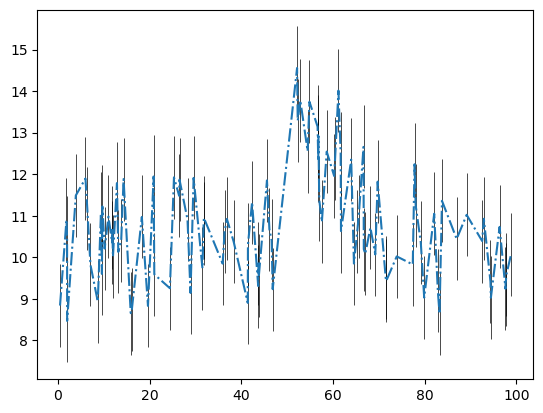

In [152]:
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt="-.", ecolor = "black", elinewidth=0.5)

In [153]:
def model(params, t):
    A, b, t0, alpha = params
    arr = []
    for i in t:
        if i<t0:    arr.append(b)
        else:       arr.append(b + A*np.exp(-alpha*(i-t0)))
    arr = np.array(arr)

    return arr

In [ ]:
def Likelihood(params, data, mod=model):
    sigma = data[:, 2]
    y = data[:, 1]
    t = data[:, 0]
    y_model = mod(params, t)

    return np.prod(np.exp(-(y-y_model)**2 /2 /sigma**2))

def Prior():
    return 1.0/10

def myPosterior(params, data, mod=model):
    return Likelihood(params, data, mod=model) * Prior()

# emcee wants ln of posterior pdf
def myLogPosterior(params, data, mod=model):
    return np.log(myPosterior(params, data, mod=model))

In [155]:
ndim = 4
nwalkers = 20
nsteps = int(1e4)

t0_quick=50
A_quick=5
b_quick=10
alpha_quick=0.1

theta_quick= np.array([A_quick,b_quick,t0_quick,alpha_quick])

#starting_guesses = np.random.randn(nwalkers, ndim)                 #this isn't working
starting_guesses = theta_quick + 1e-1* np.random.randn(nwalkers, ndim)


In [156]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, myLogPosterior, args=[data, model])
sampler.run_mcmc(starting_guesses, nsteps);

C:\Users\albad\AppData\Local\Temp\ipykernel_14700\1502509229.py:17: RuntimeWarning: divide by zero encountered in log
  return np.log(myPosterior(params, data, mod=model))


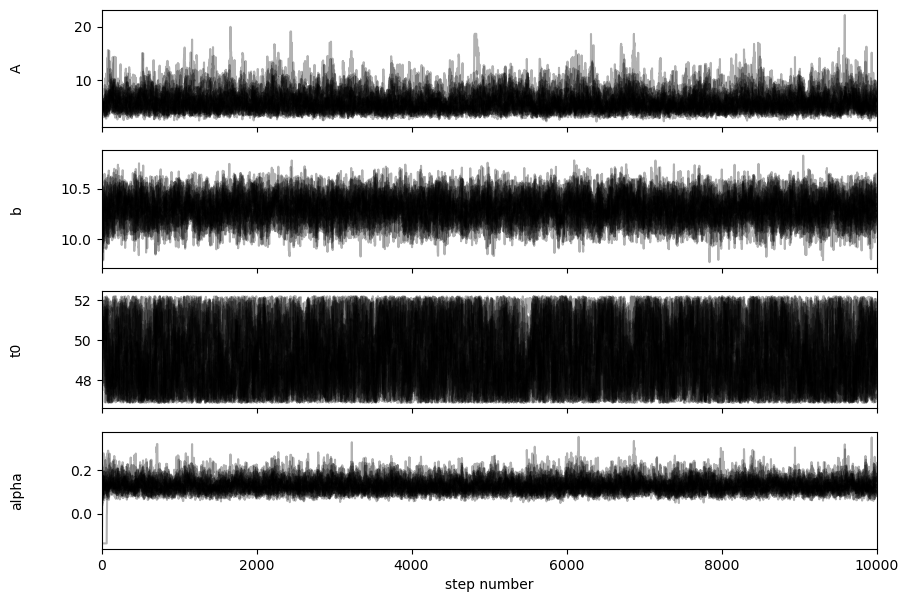

In [157]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["A","b","t0","alpha"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [158]:
tau = sampler.get_autocorr_time()
print(tau)

[78.93523822 55.96079791 79.36621712 60.38603675]


In [159]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print(flat_samples.shape)

(2460, 4)


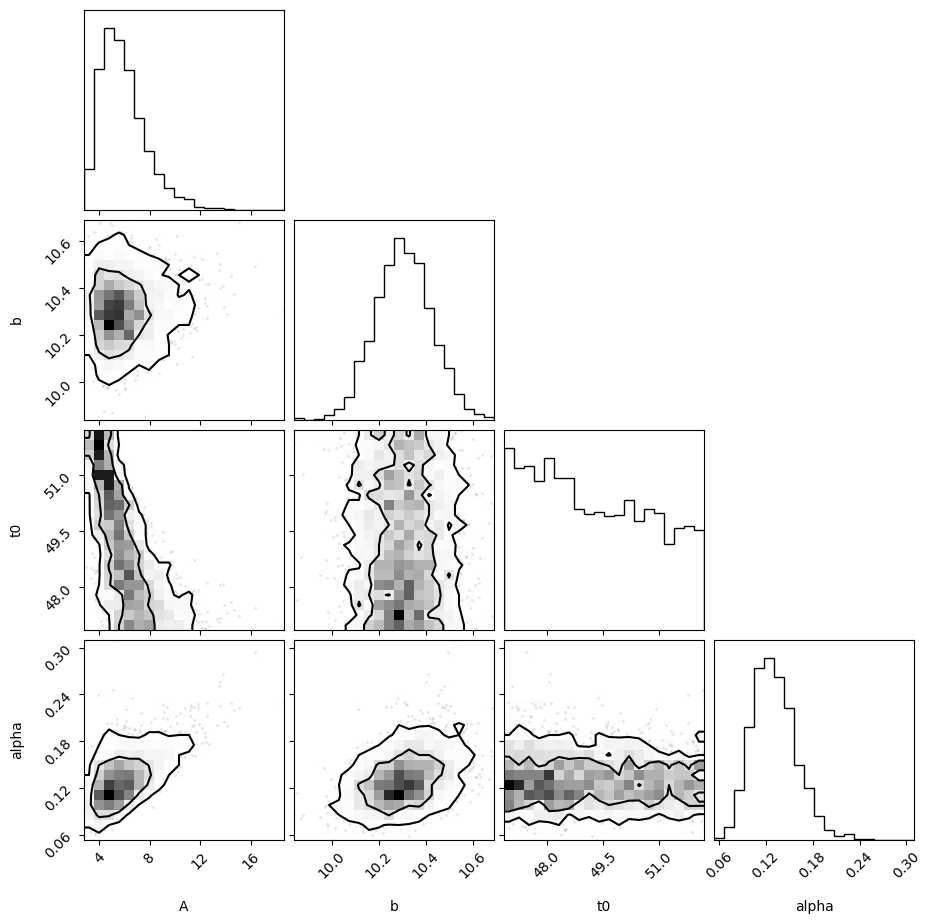

In [160]:
fig = corner.corner(
    flat_samples, labels=labels, levels=[0.68,0.95]
);